## Potoki ML
Poniższy przykład prezentuje utworzenie potoku ML, który zawiera:
- uzupełnianie brakujących danych (SimpleImputer)
- standaryzacja danych (StandardScaler)
- trnowanie modelu

Modele wybrane do klasyfikacji: SVC, Random Forest, KNN

{'SVC': Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('model', SVC(C=100, kernel='linear'))]), 'RandomForest': Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('model', RandomForestClassifier())]), 'KNN': Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])}
Dokładność SVC: 1.00
Dokładność RandomForest: 1.00
Dokładność KNN: 1.00


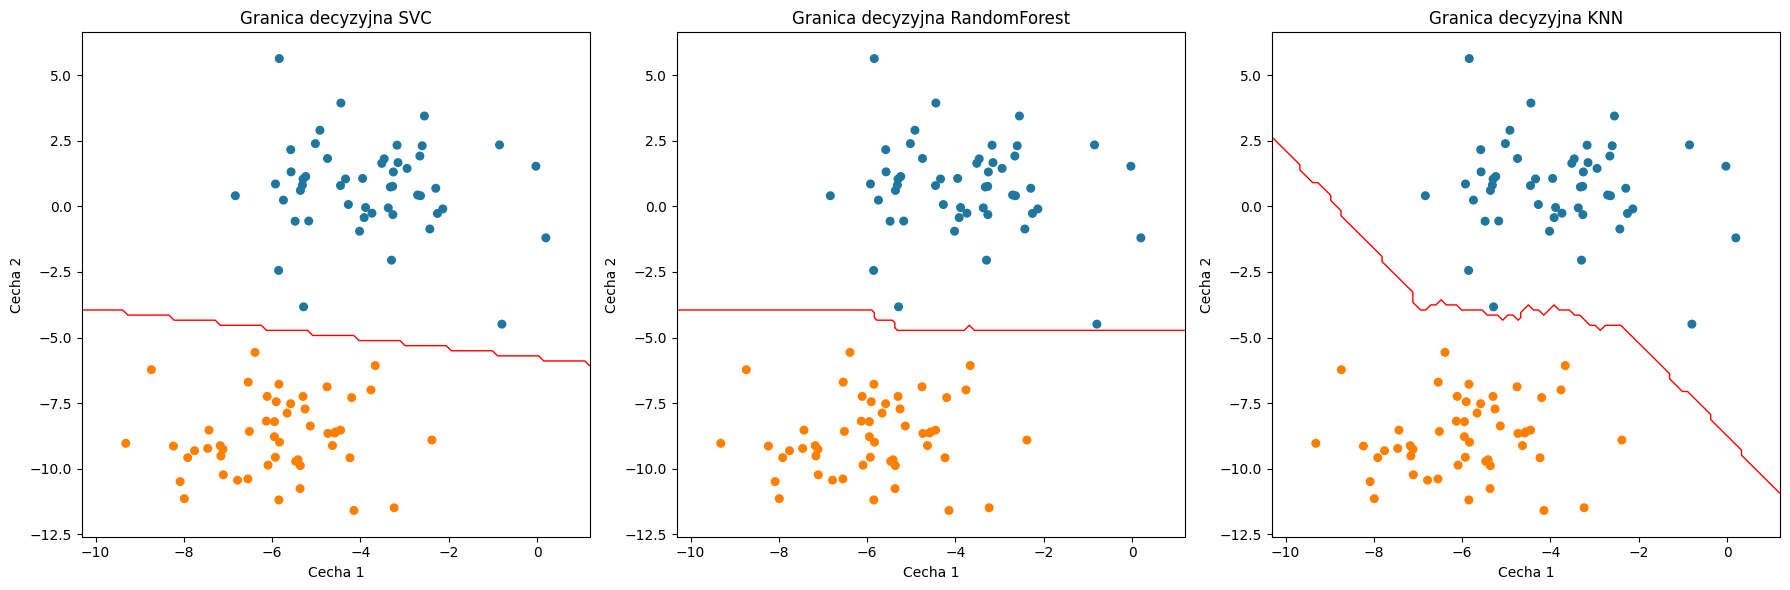

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=17, cluster_std=1.5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


models = {
    'SVC': SVC(kernel='linear', C=100),
    'RandomForest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier()
}

pipelines = {
    name: Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    for name, model in models.items()
}

print(pipelines)

accuracies = {}
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    accuracies[name] = pipeline.score(X_test, y_test)

for name, accuracy in accuracies.items():
    print(f'Dokładność {name}: {accuracy:.2f}')

plt.figure(figsize=(18, 6))
for i, (name, pipeline) in enumerate(pipelines.items(), 1):
    plt.subplot(1, 3, i)
    plt.title(f'Granica decyzyjna {name}')
    plt.xlabel("Cecha 1")
    plt.ylabel("Cecha 2")
    kolory = np.array(['#1f77a0','#ff7f00'])
    plt.scatter(X[:, 0], X[:, 1], c=kolory[y], s=30)
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = pipeline.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, levels=[0.5], colors='r', linewidths=1)

plt.tight_layout()
plt.show()